**Loan Prediction model**

WorkFlow
![Screenshot 2026-09-11 062551.png](<attachment:Screenshot 2026-09-11 062551.png>)
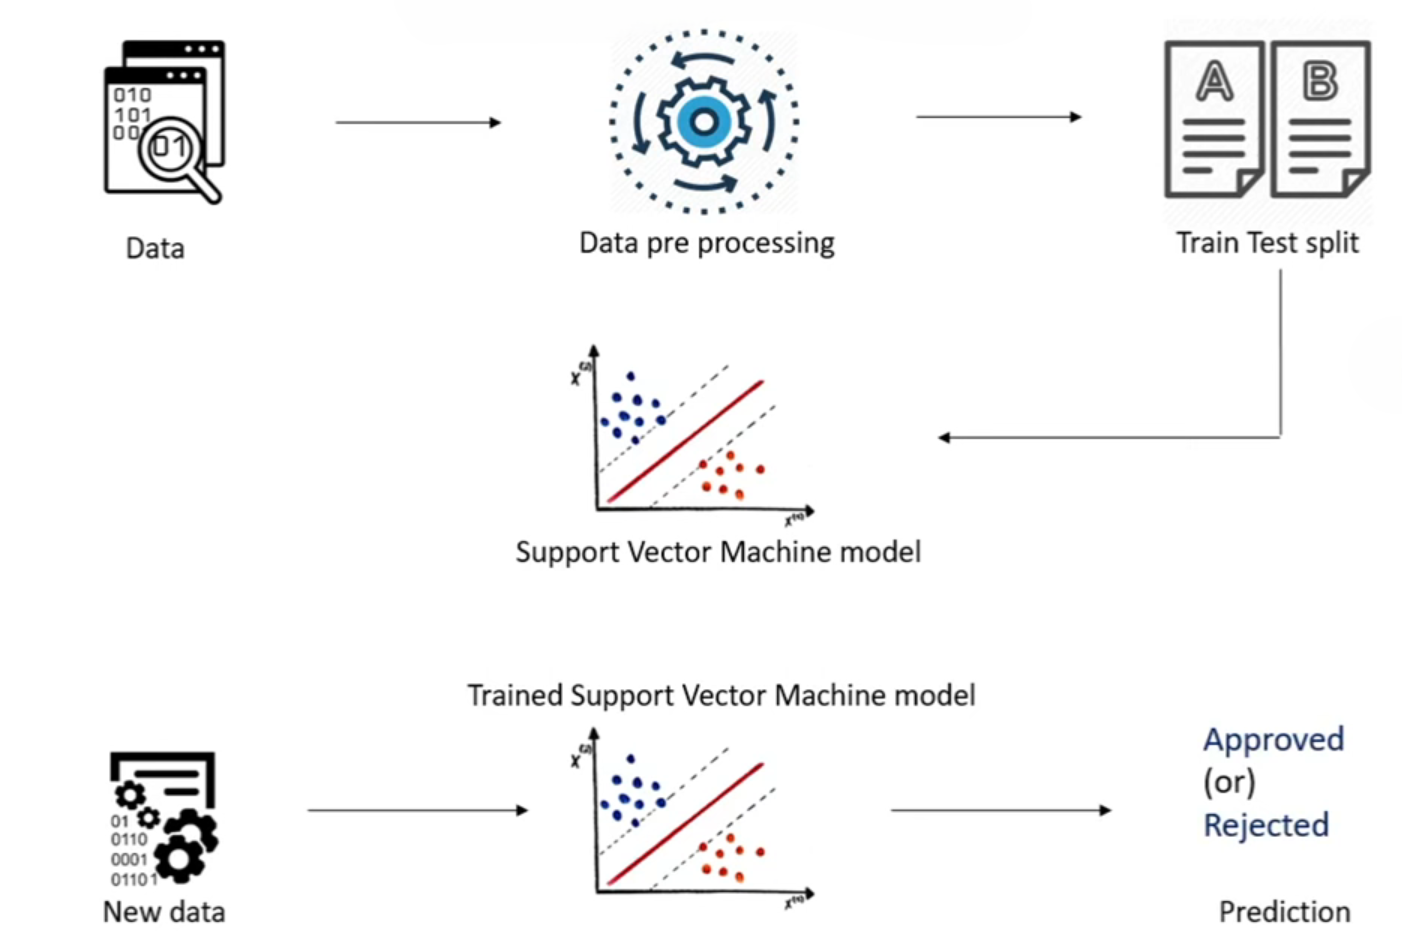

# Import the need packages

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn import svm
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset

In [5]:
loan_dataset = pd.read_csv('dataset/loan_dataset.csv')

In [6]:
# read the first 5 rows of the dataset
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
# read the last 5 rows of the dataset
loan_dataset.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [9]:
# no of the rows and columns
loan_dataset.shape

(614, 13)

In [10]:
# Know about the null data
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
# drop the missing values
loan_dataset.dropna(inplace= True)

In [12]:
# Now to know about the missing values
loan_dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
# Now shape of the dataset after the dropping the missing values
loan_dataset.shape

(480, 13)

In [14]:
# know about the statistical measures of the dataset
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,5364.231250,1581.093583,144.735417,342.050000,0.854167
std,5668.251251,2617.692267,80.508164,65.212401,0.353307
min,150.000000,0.000000,9.000000,36.000000,0.000000
25%,2898.750000,0.000000,100.000000,360.000000,1.000000
50%,3859.000000,1084.500000,128.000000,360.000000,1.000000
75%,5852.500000,2253.250000,170.000000,360.000000,1.000000
max,81000.000000,33837.000000,600.000000,480.000000,1.000000


# Label encoding

In [17]:
# encode the dataset
le = LabelEncoder()

loan_dataset.Gender = le.fit_transform(loan_dataset.Gender)
loan_dataset.Married = le.fit_transform(loan_dataset.Married)
loan_dataset.Education = le.fit_transform(loan_dataset.Education)
loan_dataset.Self_Employed = le.fit_transform(loan_dataset.Self_Employed)
loan_dataset.Property_Area = le.fit_transform(loan_dataset.Property_Area)
loan_dataset.Loan_Status = le.fit_transform(loan_dataset.Loan_Status)

In [20]:
# value count of dependents
loan_dataset['Dependents'].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

In [21]:
# replace the 3+ in dependents
loan_dataset['Dependents'] = loan_dataset['Dependents'].replace('3+', 4)

In [24]:
# After encoding and replace of 3+ in dependents
loan_dataset.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
6,LP001013,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1
7,LP001014,1,1,4,0,0,3036,2504.0,158.0,360.0,0.0,1,0
8,LP001018,1,1,2,0,0,4006,1526.0,168.0,360.0,1.0,2,1
9,LP001020,1,1,1,0,0,12841,10968.0,349.0,360.0,1.0,1,0
10,LP001024,1,1,2,0,0,3200,700.0,70.0,360.0,1.0,2,1


<Axes: xlabel='Loan_Status', ylabel='Count'>

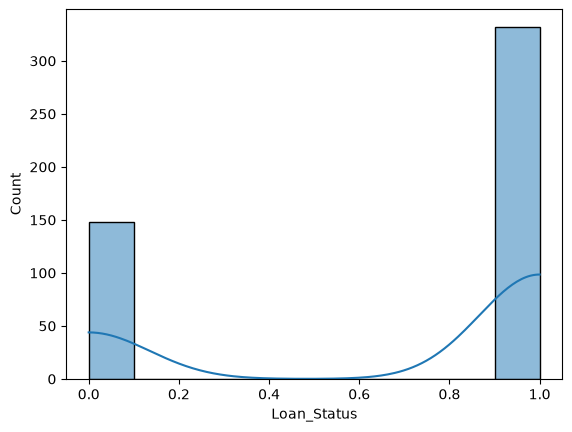

In [23]:
# Data visulazation
sns.histplot(loan_dataset['Loan_Status'], kde=True)

# Split the dataset

In [35]:
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'])
Y = loan_dataset['Loan_Status']

In [36]:
X.shape

(480, 11)

In [37]:
Y.shape

(480,)

In [38]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2


In [39]:
Y.head()

1    0
2    1
3    1
4    1
5    1
Name: Loan_Status, dtype: int64

In [40]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [41]:
X_train.shape

(384, 11)

In [42]:
X_test.shape

(96, 11)

In [43]:
Y_train.shape

(384,)

In [44]:
Y_test.shape

(96,)

# Model train

In [45]:
# train the model
model = svm.SVC(kernel='linear')

In [46]:
model.fit(X_train, Y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Model Evaluation

In [47]:
# Model evaluation
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.8020833333333334


In [48]:
# test data prediction
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.8229166666666666


# Prediction system

In [53]:
input_data = input("Enter the values with comma separated: ")

# Split input
input_data = [value.strip() for value in input_data.split(',')]

# Features used for training
columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    'Property_Area'
]

# Check number of values
if len(input_data) != len(columns):
    print(f"Expected {len(columns)} values, but received {len(input_data)} values.")

else:

    # Create DataFrame
    input_df = pd.DataFrame([input_data], columns=columns)

    # Encode categorical values
    gender_mapping = {
        'Female': 0,
        'Male': 1
    }

    married_mapping = {
        'No': 0,
        'Yes': 1
    }

    education_mapping = {
        'Graduate': 0,
        'Not Graduate': 1
    }

    self_employed_mapping = {
        'No': 0,
        'Yes': 1
    }

    property_area_mapping = {
        'Rural': 0,
        'Semiurban': 1,
        'Urban': 2
    }

    input_df['Gender'] = input_df['Gender'].map(gender_mapping)
    input_df['Married'] = input_df['Married'].map(married_mapping)
    input_df['Education'] = input_df['Education'].map(education_mapping)
    input_df['Self_Employed'] = input_df['Self_Employed'].map(self_employed_mapping)
    input_df['Property_Area'] = input_df['Property_Area'].map(property_area_mapping)

    # Handle Dependents
    input_df['Dependents'] = input_df['Dependents'].replace('3+', 4)

    # Convert numeric columns
    numeric_columns = [
        'Dependents',
        'ApplicantIncome',
        'CoapplicantIncome',
        'LoanAmount',
        'Loan_Amount_Term',
        'Credit_History'
    ]

    for col in numeric_columns:
        input_df[col] = pd.to_numeric(input_df[col])

    # Check for invalid values
    if input_df.isnull().any().any():
        print("Invalid input detected. Please check your values.")

    else:

        # Convert DataFrame to NumPy array
        input_data_as_numpy_array = np.asarray(
            input_df,
            dtype=np.float64
        )

        # Reshape
        input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

        # Prediction
        prediction = model.predict(input_data_reshaped)

        if prediction[0] == 0:
            print("The person is not eligible for the loan")
        else:
            print("The person is eligible for the loan")

Expected 11 values, but received 12 values.
